In [2]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set IEEE-friendly plotting aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2.5,
    'legend.fontsize': 12,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Define the path to our results directory
RESULTS_DIR = os.path.join('..', 'results', 'neural3')
DATASET_NAME = 'synthetic' # Change this when running on UCI datasets

In [3]:
methods = ['advi', 'qmcvi', 'yoasovi']
results_data = {}

for method in methods:
    filepath = os.path.join(RESULTS_DIR, f"{method}_{DATASET_NAME}_results.pkl")
    try:
        with open(filepath, 'rb') as f:
            results_data[method.upper()] = pickle.load(f)
        print(f"Successfully loaded {method.upper()} data.")
    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}. Have you run the training script yet?")

Successfully loaded ADVI data.
Successfully loaded QMCVI data.
Successfully loaded YOASOVI data.


In [4]:
summary_records = []

for method, data in results_data.items():
    # Get the final recorded values
    final_elbo = data['elbo'][-1]
    total_time = data['time'][-1]
    total_evals = data['evals'][-1]
    
    summary_records.append({
        'Method': method,
        'Final ELBO': final_elbo,
        'Total Time (s)': total_time,
        'Gradient Evaluations': total_evals
    })

summary_df = pd.DataFrame(summary_records).set_index('Method')
summary_df['Final ELBO'] = summary_df['Final ELBO'].round(2)
summary_df['Total Time (s)'] = summary_df['Total Time (s)'].round(3)

print(f"--- Ending Performance Summary ({DATASET_NAME.capitalize()} Data) ---")
display(summary_df)

# Optional: Export to LaTeX format for your paper
# print(summary_df.to_latex())

--- Ending Performance Summary (Synthetic Data) ---


,Final ELBO,Total Time (s),Gradient Evaluations
Method,,,
ADVI,-1701.24,18.207,2500
QMCVI,-1306.61,241.916,25000
YOASOVI,-1427.27,29.678,2500


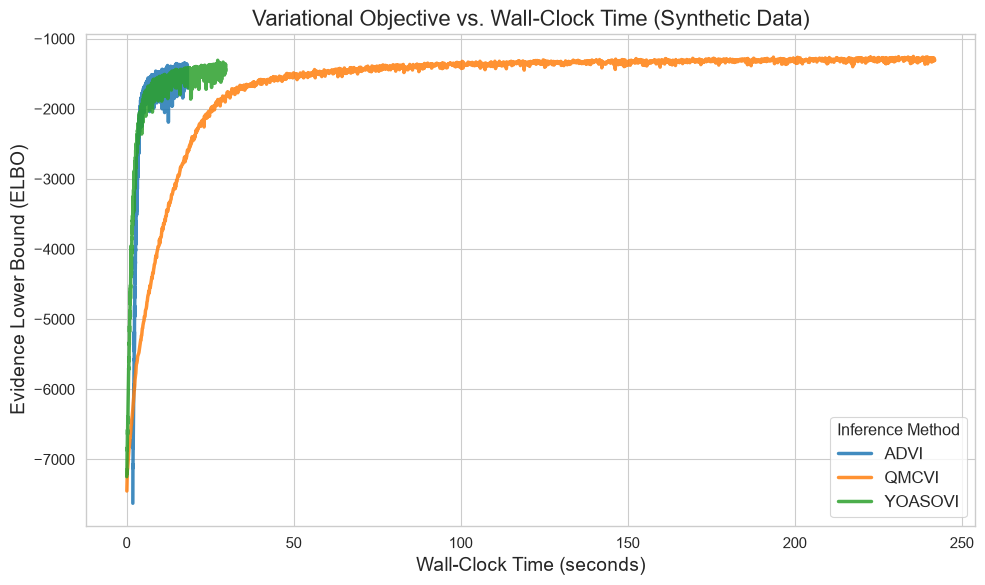

In [5]:
fig, ax = plt.subplots()

colors = {'ADVI': '#1f77b4', 'QMCVI': '#ff7f0e', 'YOASOVI': '#2ca02c'}

for method, data in results_data.items():
    ax.plot(data['time'], data['elbo'], label=method, color=colors[method], alpha=0.85)

ax.set_title(f'Variational Objective vs. Wall-Clock Time ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Wall-Clock Time (seconds)')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Depending on the data, ELBO values might be massively negative early on.
# You can uncomment the line below to set a custom y-limit to zoom in on the convergence area.
# ax.set_ylim([-5000, max([max(d['elbo']) for d in results_data.values()]) + 100])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_time_{DATASET_NAME}.png'))
plt.show()

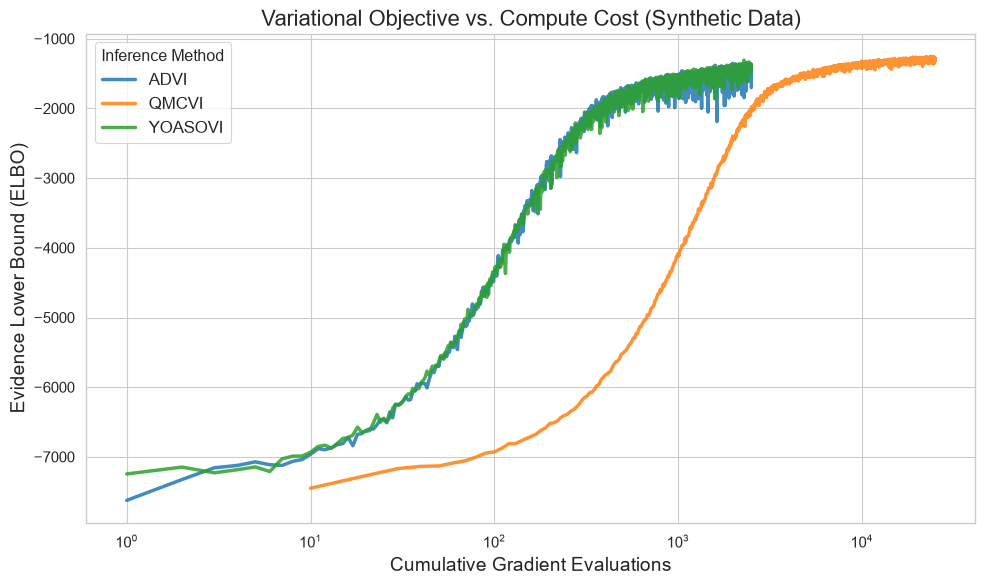

In [6]:
fig, ax = plt.subplots()

for method, data in results_data.items():
    ax.plot(data['evals'], data['elbo'], label=method, color=colors[method], alpha=0.85)

ax.set_title(f'Variational Objective vs. Compute Cost ({DATASET_NAME.capitalize()} Data)')
ax.set_xlabel('Cumulative Gradient Evaluations')
ax.set_ylabel('Evidence Lower Bound (ELBO)')
ax.legend(title='Inference Method')

# Because QMCVI does 10 evaluations per step, its x-axis will stretch much further.
# A log scale on the X-axis often makes this comparison easier to read.
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'elbo_vs_evals_{DATASET_NAME}.png'))
plt.show()